<a href="https://colab.research.google.com/github/raki-rankawat/thesis-v2/blob/master/KD_Ablation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 09 · Knowledge Distillation — Hyperparameter Ablation

Sensitivity analysis for KD hyperparameters: temperature T and weighting alpha.

**Fixed:** best teacher (ResNet18 pretrained), best student (MobileNetV3), KD-FT mode, seed=41.
**Varied:** T ∈ {2, 4, 8} and alpha ∈ {0.5, 0.7, 0.9}.

**Theoretical justification (Hinton et al., 2015):**
- Temperature T controls the softness of the teacher's output distribution.
  Higher T reveals more inter-class similarity information (dark knowledge).
  T ∈ [2, 8] is recommended for standard classification tasks.
- Alpha balances hard labels (ground truth) vs soft labels (teacher distribution).
  Higher alpha → student relies more on teacher's soft targets.

This ablation justifies our final choice of T=4, alpha=0.7 used in notebook 10.


In [9]:
# ── Mount Drive & load utils ────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import sys, shutil, os
UTILS_SRC = "/content/drive/My Drive/thesis/utils"
if os.path.exists(UTILS_SRC):
    shutil.copytree(UTILS_SRC, "/content/utils", dirs_exist_ok=True)
    sys.path.insert(0, "/content")
    print("✅ utils loaded from Drive")
else:
    sys.path.insert(0, "/content")
    print("⚠️  Place the utils/ folder at: My Drive/thesis/utils/")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ utils loaded from Drive


In [10]:
# ── Standard imports ────────────────────────────────────────────────
import os, time, random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from utils.dataset import prepare_dataset, get_loaders, get_test_loader
from utils.models  import (
    VGG_Scratch, VGG_Pretrained,
    ResNet_Scratch, ResNet18_Pretrained,
    MobileNetV2_Scratch, MobileNetV3_Pretrained,
    count_params, model_size_mb, MODEL_REGISTRY,
)
from utils.train import (
    setup_device, set_seed, evaluate,
    train_model, train_model_three_phase,
    train_multi_seed, train_kd, plot_history,
)

device = setup_device(seed=41)


Device: cuda


In [11]:
# ── Dataset setup ───────────────────────────────────────────────────
prepare_dataset()


1/4 Download
✅ VWW archive already downloaded
2/4 Extract
✅ VWW already extracted
3/4 Find root
   Root: /content/vww_work/extracted/vw_coco2014_96
4/4 Manifests
✅ Manifests already exist: /content/drive/My Drive/vww_fixed_split_manifests


PosixPath('/content/vww_work/extracted/vw_coco2014_96')

In [12]:
SAVE_DIR = "/content/drive/My Drive/Colab Notebooks"


In [17]:
# ── Set these after running notebooks 04 and 07 ──────────────────────
TEACHER_CKPT     = f"{SAVE_DIR}/vgg_pretrained_seed_63.pth"
STUDENT_CKPT     = f"{SAVE_DIR}/mobilenetv2_baseline_seed_41.pth"
TEACHER_MODEL_FN = VGG_Pretrained
STUDENT_MODEL_FN = MobileNetV2_Scratch


In [18]:
train_loader, val_loader = get_loaders(batch_size=64, augmentation="minimal")

# Load teacher once
teacher = TEACHER_MODEL_FN().to(device)
teacher.load_state_dict(torch.load(TEACHER_CKPT, map_location=device))
teacher_acc = evaluate(teacher, val_loader, device)
print(f"Teacher accuracy: {teacher_acc*100:.2f}%")

# Student baseline (pre-KD)
student_base = STUDENT_MODEL_FN().to(device)
student_base.load_state_dict(torch.load(STUDENT_CKPT, map_location=device))
baseline_acc = evaluate(student_base, val_loader, device)
print(f"Student baseline: {baseline_acc*100:.2f}%")


Train: 7000 | Val: 1500 | Batch: 64
Teacher accuracy: 88.07%
Student baseline: 78.80%


In [19]:
# ── Ablation grid ────────────────────────────────────────────────────
import copy

ABLATION_GRID = [
    {"T": 2.0, "alpha": 0.7, "label": "T=2, α=0.7"},
    {"T": 4.0, "alpha": 0.5, "label": "T=4, α=0.5"},
    {"T": 4.0, "alpha": 0.7, "label": "T=4, α=0.7 ← default"},
    {"T": 4.0, "alpha": 0.9, "label": "T=4, α=0.9"},
    {"T": 8.0, "alpha": 0.7, "label": "T=8, α=0.7"},
]

ablation_results = []

for cfg in ABLATION_GRID:
    print(f"\n{'─'*50}")
    print(f"Running: {cfg['label']}")
    set_seed(41)
    student = STUDENT_MODEL_FN().to(device)
    student.load_state_dict(torch.load(STUDENT_CKPT, map_location=device))   # FT mode

    save_path = f"{SAVE_DIR}/ablation_{cfg['label'].replace(' ','_').replace('=','')}.pth"

    best_acc, elapsed = train_kd(
        student=student, teacher=teacher,
        train_loader=train_loader, val_loader=val_loader, device=device,
        epochs=20, lr=1e-3, weight_decay=1e-4,
        temperature=cfg["T"], alpha=cfg["alpha"],
        patience=8, save_path=save_path, verbose=False,
    )
    delta = best_acc - baseline_acc
    ablation_results.append({
        "Config": cfg["label"], "T": cfg["T"], "alpha": cfg["alpha"],
        "KD Val Acc (%)": round(best_acc*100, 2),
        "Δ vs baseline (%)": round(delta*100, 2),
        "Time (min)": round(elapsed, 1),
    })
    print(f"  → {best_acc*100:.2f}%  (Δ {delta*100:+.2f}%)")



──────────────────────────────────────────────────
Running: T=2, α=0.7
Initial student accuracy: 78.80%
🛑 Early stopping at epoch 8

✅ Best KD val acc: 78.80%  (1.7 min)
  → 78.80%  (Δ +0.00%)

──────────────────────────────────────────────────
Running: T=4, α=0.5
Initial student accuracy: 78.80%
🛑 Early stopping at epoch 8

✅ Best KD val acc: 78.80%  (1.7 min)
  → 78.80%  (Δ +0.00%)

──────────────────────────────────────────────────
Running: T=4, α=0.7 ← default
Initial student accuracy: 78.80%
🛑 Early stopping at epoch 8

✅ Best KD val acc: 78.80%  (1.7 min)
  → 78.80%  (Δ +0.00%)

──────────────────────────────────────────────────
Running: T=4, α=0.9
Initial student accuracy: 78.80%
🛑 Early stopping at epoch 8

✅ Best KD val acc: 78.80%  (1.6 min)
  → 78.80%  (Δ +0.00%)

──────────────────────────────────────────────────
Running: T=8, α=0.7
Initial student accuracy: 78.80%
🛑 Early stopping at epoch 8

✅ Best KD val acc: 78.80%  (1.6 min)
  → 78.80%  (Δ +0.00%)


In [20]:
import pandas as pd
df_abl = pd.DataFrame(ablation_results).set_index("Config")
print("\n" + df_abl.to_string())

best_cfg = df_abl["KD Val Acc (%)"].idxmax()
print(f"\n✅ Best config: {best_cfg}  ({df_abl.loc[best_cfg,'KD Val Acc (%)']:.2f}%)")
print(f"   Baseline: {baseline_acc*100:.2f}%  |  Teacher: {teacher_acc*100:.2f}%")
print("\n→ Use best config in notebook 10_KD_Main.ipynb")



                        T  alpha  KD Val Acc (%)  Δ vs baseline (%)  Time (min)
Config                                                                         
T=2, α=0.7            2.0    0.7            78.8                0.0         1.7
T=4, α=0.5            4.0    0.5            78.8                0.0         1.7
T=4, α=0.7 ← default  4.0    0.7            78.8                0.0         1.7
T=4, α=0.9            4.0    0.9            78.8                0.0         1.6
T=8, α=0.7            8.0    0.7            78.8                0.0         1.6

✅ Best config: T=2, α=0.7  (78.80%)
   Baseline: 78.80%  |  Teacher: 88.07%

→ Use best config in notebook 10_KD_Main.ipynb


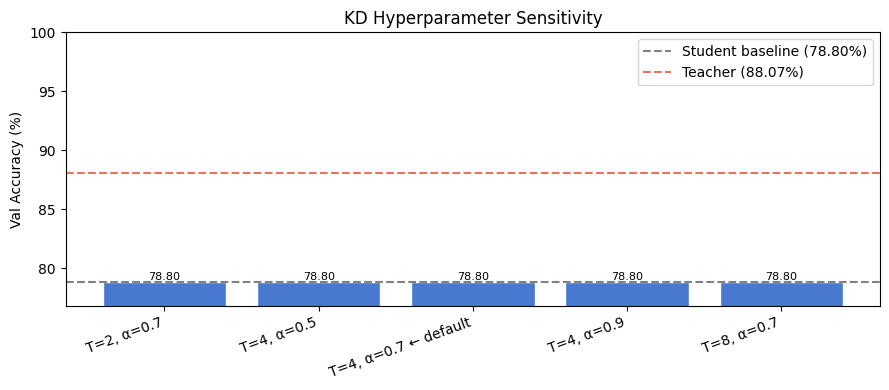

In [21]:
# ── Sensitivity plot ──────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(df_abl.index, df_abl["KD Val Acc (%)"], color="#4878D0", edgecolor="white")
ax.axhline(baseline_acc*100, color="gray",   linestyle="--", label=f"Student baseline ({baseline_acc*100:.2f}%)")
ax.axhline(teacher_acc*100,  color="#E8735A", linestyle="--", label=f"Teacher ({teacher_acc*100:.2f}%)")
ax.set_ylabel("Val Accuracy (%)"); ax.set_title("KD Hyperparameter Sensitivity")
ax.set_ylim(min(df_abl["KD Val Acc (%)"].min(), baseline_acc*100) - 2, 100)
for p in bars:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=8)
ax.legend(); plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()
